# Subject 1 Encoding Analysis (RSA prep)

## Analysing Our Encodings vs CLIP encodings
Now we see we can encode our Schafer data into 768 dimms reliably, let's start analyzing the two forms of encoding, and looking for similarities in structure.

In [ ]:
from __future__ import annotations

# --- Imports ---
import glob
import json
import os
from dataclasses import dataclass
from functools import lru_cache
from pathlib import Path
from typing import Any

import numpy as np

In [2]:
# --- Configuration (edit these if needed) ---
REPO_ROOT = Path.cwd()
PROCESSED_DIR = REPO_ROOT / "processed_data"
SUBJECT = "CSI1"
VARIANT = "schaefer1014"
CLIP_JSON_PATH = REPO_ROOT / "ClipEmbeddings.json"
STIMULI_DIR = "/media/hdd/BOLD5000/BOLD5000_Stimuli/Scene_Stimuli/Presented_Stimuli"
AE_CKPT = REPO_ROOT / "AutoencoderModels" / "CSI1_schaefer1014_ae_denoising.pt"

print('repo:', REPO_ROOT)
print('subject:', SUBJECT)
print('npz:', PROCESSED_DIR / SUBJECT / f'{SUBJECT}_{VARIANT}.npz')
print('clip json:', CLIP_JSON_PATH)
print('stimuli dir:', STIMULI_DIR)
print('ae ckpt:', AE_CKPT)

repo: /home/mariop/Documents/Programming/bold5000-gan
subject: CSI1
npz: /home/mariop/Documents/Programming/bold5000-gan/processed_data/CSI1/CSI1_schaefer1014.npz
clip json: /home/mariop/Documents/Programming/bold5000-gan/ClipEmbeddings.json
stimuli dir: /media/hdd/BOLD5000/BOLD5000_Stimuli/Scene_Stimuli/Presented_Stimuli
ae ckpt: /home/mariop/Documents/Programming/bold5000-gan/AutoencoderModels/CSI1_schaefer1014_ae_denoising.pt


In [8]:
# --- Small helpers: load subject npz and find the main data array ---
def _npz_path(subject: str, variant: str) -> Path:
    return PROCESSED_DIR / subject / f"{subject}_{variant}.npz"

def reconstruct_raw_imagename(name: Any) -> str:
    # imgnames sometimes come out of npz as bytes
    if isinstance(name, (bytes, np.bytes_)):
        name = name.decode("utf-8", errors="replace")
    return os.path.basename(str(name))

def load_npz(path: Path, *, allow_pickle: bool = True) -> dict[str, np.ndarray]:
    with np.load(path, allow_pickle=allow_pickle) as f:
        return {k: f[k] for k in f.files}

def find_data_array(npz: dict[str, np.ndarray]) -> tuple[str, np.ndarray]:
    """Return (key, array) for the main 2D+ numeric data matrix in a subject npz."""
    # Prefer common keys; otherwise pick the largest numeric 2D+ array.
    for k in ["X", "data", "betas", "features", "fmri", "roi_data", "roi_betas"]:
        if k in npz and isinstance(npz[k], np.ndarray) and npz[k].ndim >= 2:
            return k, npz[k]

    best_k: str | None = None
    best: np.ndarray | None = None
    best_size = -1
    for k, a in npz.items():
        if not isinstance(a, np.ndarray):
            continue
        if a.dtype.kind not in "iufb" or a.ndim < 2:
            continue
        if a.size > best_size:
            best_k, best, best_size = k, a, a.size
    if best_k is None or best is None:
        raise ValueError("No numeric 2D+ array found in subject npz")
    return best_k, best

In [9]:
# --- Load CLIP embeddings + human-readable labels (one entry per unique image) ---
def load_clip_lookup(path: Path) -> tuple[dict[str, np.ndarray], dict[str, list[str]]]:
    with open(path, 'r') as f:
        payload = json.load(f)
    clip_lookup: dict[str, np.ndarray] = {}
    label_lookup: dict[str, list[str]] = {}
    for it in payload.get('items', []):
        name = reconstruct_raw_imagename(it['imgname'])
        clip_lookup[name] = np.asarray(it['clip_embedding'], dtype=np.float32)
        label_lookup[name] = list(it.get('labels', []))
    return clip_lookup, label_lookup

CLIP_LOOKUP, HUMAN_LABEL_LOOKUP = load_clip_lookup(CLIP_JSON_PATH)
print('n unique images in CLIP json:', len(CLIP_LOOKUP))

n unique images in CLIP json: 4916


In [12]:
# --- Map an imgname (basename) -> full on-disk stimulus path ---
@lru_cache(maxsize=1)
def _build_image_map(stimuli_dir: str = STIMULI_DIR) -> dict[str, str]:
    exts = ("*.jpg", "*.jpeg", "*.JPEG", "*.png")
    paths: list[str] = []
    for ext in exts:
        paths += glob.glob(f"{stimuli_dir}/**/{ext}", recursive=True)
    return {os.path.basename(p): p for p in paths}

def resolve_raw_image_path(imgname: str) -> str | None:
    """Return the on-disk stimulus path for an imgname, or None if missing."""
    key = reconstruct_raw_imagename(imgname)
    m = _build_image_map()
    return m.get(key)

In [13]:
# --- Build per-image rows for Subject 1, aligned across X/CLIP/labels/paths ---
@dataclass(frozen=True)
class Trial:
    imgname: str
    x: np.ndarray
    clip: np.ndarray
    labels: list[str]
    image_path: str | None

def build_trials(*, subject: str = SUBJECT, variant: str = VARIANT) -> tuple[list[Trial], str]:
    meta = load_npz(_npz_path(subject, variant), allow_pickle=True)
    data_key, X_all = find_data_array(meta)
    img_all = meta["imgnames"]

    seen: set[str] = set()
    trials: list[Trial] = []
    dropped_missing_clip = 0
    missing_image_path = 0

    # The subject npz may contain repeated presentations; we keep one row per unique image
    for i in range(X_all.shape[0]):
        name = reconstruct_raw_imagename(img_all[i])
        if name in seen:
            continue
        seen.add(name)
        if name not in CLIP_LOOKUP:
            dropped_missing_clip += 1
            continue
        p = resolve_raw_image_path(name)
        if p is None:
            missing_image_path += 1
        trials.append(
            Trial(
                imgname=name,
                x=np.asarray(X_all[i], dtype=np.float32),
                clip=CLIP_LOOKUP[name],
                labels=HUMAN_LABEL_LOOKUP.get(name, []),
                image_path=p,
            )
        )

    print("subject data key:", data_key)
    print("unique images kept:", len(trials))
    print("dropped (missing CLIP):", dropped_missing_clip)
    print("missing stimulus path:", missing_image_path)
    return trials, data_key

trials, X_KEY = build_trials()
imgnames = [t.imgname for t in trials]
labels = [t.labels for t in trials]
image_paths = [t.image_path for t in trials]
X = np.stack([t.x for t in trials], axis=0)
E_clip = np.stack([t.clip for t in trials], axis=0)
print("X:", X.shape, "E_clip:", E_clip.shape)

subject data key: betas
unique images kept: 4916
dropped (missing CLIP): 0
missing stimulus path: 0
X: (4916, 1014) E_clip: (4916, 768)


In [14]:
# --- Load saved brain embeddings (E_brain) and build RSA-ready matrices ---
AUTO_NPZ_PATH = PROCESSED_DIR / SUBJECT / f"{SUBJECT}_autoEmbeddings.npz"
auto = np.load(AUTO_NPZ_PATH, allow_pickle=True)

imgnames = [reconstruct_raw_imagename(x) for x in auto["imgnames"].tolist()]
labels = auto["labels"].tolist()
E_brain = np.asarray(auto["Z"], dtype=np.float32)

E_clip = np.stack([CLIP_LOOKUP[n] for n in imgnames], axis=0).astype(np.float32)
image_paths = [resolve_raw_image_path(n) for n in imgnames]

n_missing_paths = sum(p is None for p in image_paths)
print("loaded:", AUTO_NPZ_PATH)
print("E_brain:", E_brain.shape, "E_clip:", E_clip.shape)
print("missing stimulus paths:", n_missing_paths)
print("example:", imgnames[0], labels[0])

loaded: /home/mariop/Documents/Programming/bold5000-gan/processed_data/CSI1/CSI1_autoEmbeddings.npz
E_brain: (4916, 768) E_clip: (4916, 768)
missing stimulus paths: 0
example: n01930112_19568.JPEG ['nematode']


## Matrices ready for RSA

## RSA: compare geometry of CLIP vs brain-AE spaces

We’ll compute Representational Dissimilarity Matrices (RDMs) for `E_clip` and `E_brain`, then correlate the **upper triangles** (unique pairwise distances).

- Distance metric: cosine distance (1 - cosine similarity)
- Correlation: Spearman (rank-based, robust to monotonic scaling differences)
- Then we’ll repeat RSA within semantic categories (using `labels`).

In [15]:
# --- RSA utilities (small + dependency-free) ---
from typing import Iterable, Sequence

def _row_l2_normalize(x: np.ndarray, *, eps: float = 1e-8) -> np.ndarray:
    """Row-wise L2 normalize. Works for float32/float64."""
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.maximum(norms, eps)

def rdm_cosine(x: np.ndarray) -> np.ndarray:
    """Cosine distance RDM: D[i,j] = 1 - cos(x_i, x_j)."""
    x = np.asarray(x)
    x = _row_l2_normalize(x)
    # cosine similarity is just dot product after normalization
    sim = x @ x.T
    sim = np.clip(sim, -1.0, 1.0)
    return 1.0 - sim

def rdm_upper_triangle(D: np.ndarray, *, k: int = 1) -> np.ndarray:
    """Flatten the upper triangle of a square matrix as a 1D vector."""
    if D.ndim != 2 or D.shape[0] != D.shape[1]:
        raise ValueError(f"Expected square matrix, got {D.shape}")
    iu = np.triu_indices(D.shape[0], k=k)
    return D[iu]

def _rankdata_average_ties(x: np.ndarray) -> np.ndarray:
    """Rank data with average ranks for ties (1..n)."""
    x = np.asarray(x)
    order = np.argsort(x, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.float64)
    ranks[order] = np.arange(1, x.size + 1, dtype=np.float64)
    # resolve ties by assigning the average rank within each tie group
    xs = x[order]
    i = 0
    while i < xs.size:
        j = i + 1
        while j < xs.size and xs[j] == xs[i]:
            j += 1
        if j - i > 1:
            avg = (i + 1 + j) / 2.0
            ranks[order[i:j]] = avg
        i = j
    return ranks

def spearmanr_fast(a: np.ndarray, b: np.ndarray) -> float:
    """Spearman correlation computed as Pearson correlation on ranks."""
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    if a.size != b.size:
        raise ValueError("Inputs must have same size")
    ra = _rankdata_average_ties(a)
    rb = _rankdata_average_ties(b)
    ra = ra - ra.mean()
    rb = rb - rb.mean()
    denom = float(np.linalg.norm(ra) * np.linalg.norm(rb))
    if denom == 0.0:
        return float("nan")
    return float((ra @ rb) / denom)

def rsa_spearman(x1: np.ndarray, x2: np.ndarray) -> dict[str, Any]:
    """Return RSA summary dict between two embedding matrices."""
    if x1.shape[0] != x2.shape[0]:
        raise ValueError("x1 and x2 must have the same number of rows")
    D1 = rdm_cosine(x1)
    D2 = rdm_cosine(x2)
    u1 = rdm_upper_triangle(D1)
    u2 = rdm_upper_triangle(D2)
    rho = spearmanr_fast(u1, u2)
    return {"n": int(x1.shape[0]), "metric": "cosine", "rho": rho}

In [16]:
# --- RSA (all images) ---
rsa_all = rsa_spearman(E_clip, E_brain)
print(rsa_all)

{'n': 4916, 'metric': 'cosine', 'rho': 0.04117592667389302}


### Interpreting `rho`
- `rho` is the Spearman correlation between the **pairwise cosine distances** in CLIP space and brain-AE space.
- Here `rho ≈ 0.041` (with ~12M unique pairs). That’s **small, but not automatically “nothing”**: with this many pairs, even small effects can be reliable.
- Practically: the two spaces share **a weak but detectable global ordering** of which images are similar vs dissimilar.
- The category-split RSA is often more informative: some semantic groups can show stronger alignment than the global average.

In [18]:
# --- Visualizations (lightweight, presentation-ready) ---
import matplotlib.pyplot as plt

def _choose_subset(n: int, *, max_n: int = 200, seed: int = 0) -> np.ndarray:
    """Pick indices for a subset (for fast plotting)."""
    rng = np.random.default_rng(seed)
    if n <= max_n:
        return np.arange(n)
    return np.sort(rng.choice(n, size=max_n, replace=False))

def plot_rdms(*, E1: np.ndarray, E2: np.ndarray, title1: str, title2: str, max_n: int = 200, seed: int = 0) -> dict[str, Any]:
    idx = _choose_subset(E1.shape[0], max_n=max_n, seed=seed)
    D1 = rdm_cosine(E1[idx])
    D2 = rdm_cosine(E2[idx])
    u1 = rdm_upper_triangle(D1)
    u2 = rdm_upper_triangle(D2)
    rho = spearmanr_fast(u1, u2)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
    im0 = axes[0].imshow(D1, cmap="viridis", vmin=0, vmax=2)
    axes[0].set_title(f"{title1} RDM (n={idx.size})")
    axes[0].set_xlabel("image")
    axes[0].set_ylabel("image")
    fig.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(D2, cmap="viridis", vmin=0, vmax=2)
    axes[1].set_title(f"{title2} RDM (n={idx.size})")
    axes[1].set_xlabel("image")
    axes[1].set_ylabel("image")
    fig.colorbar(im1, ax=axes[1], fraction=0.046)

    fig.suptitle(f"Subset RSA (Spearman rho on upper triangle): {rho:+.4f}")
    plt.show()
    return {"subset_n": int(idx.size), "rho": float(rho)}

def plot_distance_scatter(*, E1: np.ndarray, E2: np.ndarray, title: str, max_n: int = 300, seed: int = 0) -> dict[str, Any]:
    idx = _choose_subset(E1.shape[0], max_n=max_n, seed=seed)
    D1 = rdm_cosine(E1[idx])
    D2 = rdm_cosine(E2[idx])
    u1 = rdm_upper_triangle(D1)
    u2 = rdm_upper_triangle(D2)
    rho = spearmanr_fast(u1, u2)

    # downsample pairs for plotting (upper triangle length is ~n^2/2)
    rng = np.random.default_rng(seed)
    m = u1.size
    K = min(20000, m)
    pick = rng.choice(m, size=K, replace=False)
    x = u1[pick]
    y = u2[pick]

    plt.figure(figsize=(5, 5))
    plt.scatter(x, y, s=4, alpha=0.15)
    plt.xlabel("CLIP cosine distance")
    plt.ylabel("Brain-AE cosine distance")
    plt.title(f"{title}\nsubset n={idx.size}, pairs={K}, Spearman rho={rho:+.4f}")
    plt.grid(True, alpha=0.2)
    plt.show()
    return {"subset_n": int(idx.size), "pairs_plotted": int(K), "rho": float(rho)}

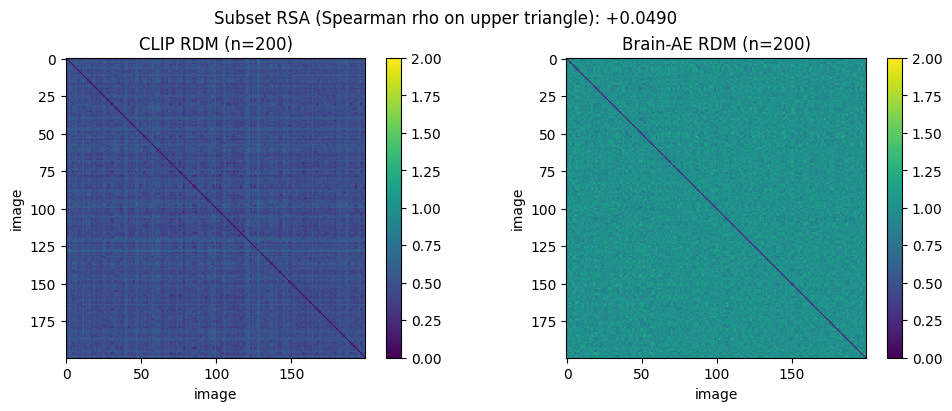

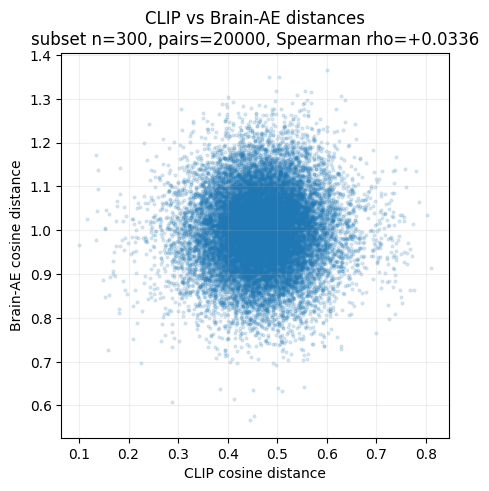

In [21]:
# --- Plots: RDM heatmaps + distance scatter (subset for speed) ---
_ = plot_rdms(E1=E_clip, E2=E_brain, title1="CLIP", title2="Brain-AE", max_n=200, seed=0)
_ = plot_distance_scatter(E1=E_clip, E2=E_brain, title="CLIP vs Brain-AE distances", max_n=300, seed=0)

In [17]:
# --- RSA split by semantic category (using the first label as primary) ---
def primary_label(lbls: Any) -> str | None:
    if lbls is None:
        return None
    if isinstance(lbls, (list, tuple)) and len(lbls) > 0:
        return str(lbls[0])
    return None

primary = [primary_label(l) for l in labels]
primary = [p if p not in ("", "None") else None for p in primary]

# count per label
counts: dict[str, int] = {}
for p in primary:
    if p is None:
        continue
    counts[p] = counts.get(p, 0) + 1

MIN_N = 50  # keep this fairly large so category RSA isn't too noisy
kept_labels = sorted([k for k, v in counts.items() if v >= MIN_N])
print(f"primary labels total: {len(counts)} | kept (n>={MIN_N}): {len(kept_labels)}")

rows: list[dict[str, Any]] = []
for lab in kept_labels:
    idx = np.array([p == lab for p in primary], dtype=bool)
    out = rsa_spearman(E_clip[idx], E_brain[idx])
    rows.append({"label": lab, **out})

# sort by rho desc
rows = sorted(rows, key=lambda d: (-(d["rho"] if d["rho"] == d["rho"] else -1e9), -d["n"]))

# print top + bottom
def _fmt_row(r: dict[str, Any]) -> str:
    return f"{r['label']:<20} n={r['n']:<4d} rho={r['rho']:+.4f}"

print("\nTop categories:")
for r in rows[:10]:
    print(_fmt_row(r))

print("\nBottom categories:")
for r in rows[-10:]:
    print(_fmt_row(r))

primary labels total: 1270 | kept (n>=50): 10

Top categories:
train                n=57   rho=+0.1119
dog                  n=61   rho=+0.0992
bottle               n=69   rho=+0.0939
airplane             n=57   rho=+0.0723
car                  n=61   rho=+0.0659
zebra                n=63   rho=+0.0614
person               n=365  rho=+0.0446
giraffe              n=76   rho=+0.0428
bird                 n=65   rho=+0.0141
clock                n=61   rho=-0.0090

Bottom categories:
train                n=57   rho=+0.1119
dog                  n=61   rho=+0.0992
bottle               n=69   rho=+0.0939
airplane             n=57   rho=+0.0723
car                  n=61   rho=+0.0659
zebra                n=63   rho=+0.0614
person               n=365  rho=+0.0446
giraffe              n=76   rho=+0.0428
bird                 n=65   rho=+0.0141
clock                n=61   rho=-0.0090


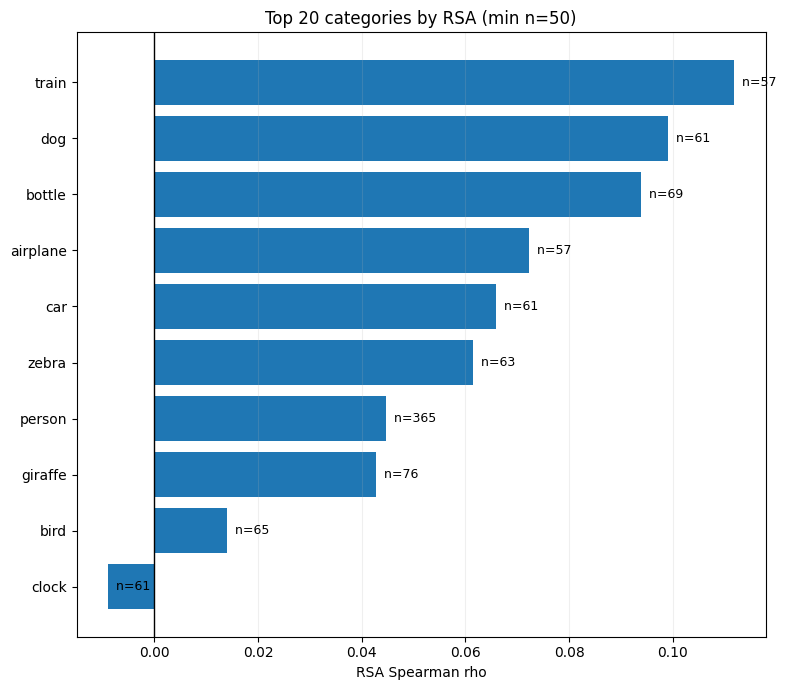

In [22]:
# --- Plot: category RSA (top 20 by rho) ---
topN = 20
top = rows[:topN]
labs = [r["label"] for r in top][::-1]
rhos = [r["rho"] for r in top][::-1]
ns = [r["n"] for r in top][::-1]

plt.figure(figsize=(8, 7))
plt.barh(labs, rhos)
plt.axvline(0.0, color="k", linewidth=1)
plt.xlabel("RSA Spearman rho")
plt.title(f"Top {topN} categories by RSA (min n={MIN_N})")
plt.grid(True, axis="x", alpha=0.2)
for y, (rho, n) in enumerate(zip(rhos, ns)):
    plt.text(rho, y, f"  n={n}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## Similarity clustering (structure without RSA)
RSA gives one global number. Another way to see structure is: **do similar images cluster together**, and do the clusters look semantic?

We’ll do 3 things:
1. Build a kNN graph / local-neighborhood view (implicitly through clustering).
2. Cluster embeddings using cosine distance (fast).
3. Visualize clusters in 2D with UMAP and summarize the dominant labels per cluster.

> Note: clustering isn’t “ground truth”; it’s a diagnostic. We’re looking for *coherent* clusters and whether Brain-AE clusters resemble CLIP clusters.

In [23]:
# --- Clustering helpers ---
from collections import Counter, defaultdict

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

try:
    import umap  # type: ignore
    _HAS_UMAP = True
except Exception:
    umap = None
    _HAS_UMAP = False

def l2_normalize_rows(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.maximum(norms, eps)

def kmeans_cosine(x: np.ndarray, *, n_clusters: int, seed: int = 0) -> np.ndarray:
    """Approximate cosine clustering via KMeans on L2-normalized vectors."""
    x = l2_normalize_rows(x)
    km = KMeans(n_clusters=n_clusters, n_init="auto", random_state=seed)
    return km.fit_predict(x)

def summarize_clusters(*, cluster_id: np.ndarray, labels_list: list[list[str]], top_k: int = 5) -> list[dict[str, Any]]:
    """Return per-cluster size + top label counts using primary label = labels[0]."""
    primary = [lbls[0] if isinstance(lbls, list) and len(lbls) > 0 else None for lbls in labels_list]
    out: list[dict[str, Any]] = []
    for c in sorted(set(cluster_id.tolist())):
        idx = np.where(cluster_id == c)[0]
        prim = [primary[i] for i in idx if primary[i] is not None]
        cnt = Counter(prim)
        out.append({
            "cluster": int(c),
            "n": int(idx.size),
            "top_labels": cnt.most_common(top_k),
        })
    out.sort(key=lambda d: -d["n"])
    return out

def embed_2d(x: np.ndarray, *, seed: int = 0) -> np.ndarray:
    """2D embedding for visualization (UMAP if available; else PCA)."""
    x = l2_normalize_rows(x)
    if _HAS_UMAP:
        reducer = umap.UMAP(n_components=2, metric="cosine", random_state=seed)
        return reducer.fit_transform(x).astype(np.float32)
    # fallback: PCA (fast, linear)
    return PCA(n_components=2, random_state=seed).fit_transform(x).astype(np.float32)

def plot_embedding_with_clusters(x2: np.ndarray, cluster_id: np.ndarray, *, title: str) -> None:
    plt.figure(figsize=(6, 5))
    plt.scatter(x2[:, 0], x2[:, 1], c=cluster_id, s=6, alpha=0.6, cmap="tab20")
    plt.title(title)
    plt.xlabel("dim 1")
    plt.ylabel("dim 2")
    plt.grid(True, alpha=0.15)
    plt.tight_layout()
    plt.show()

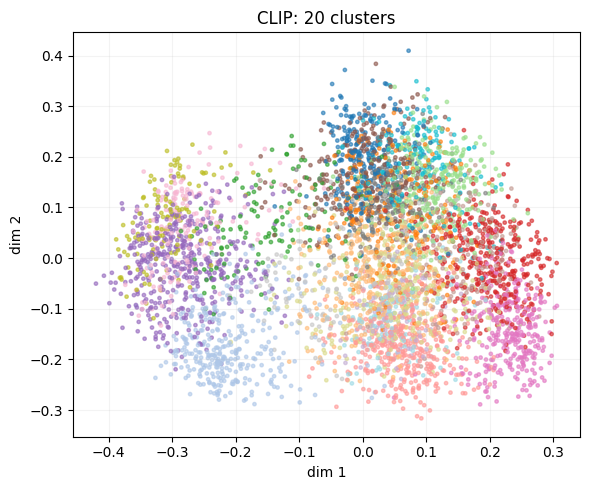

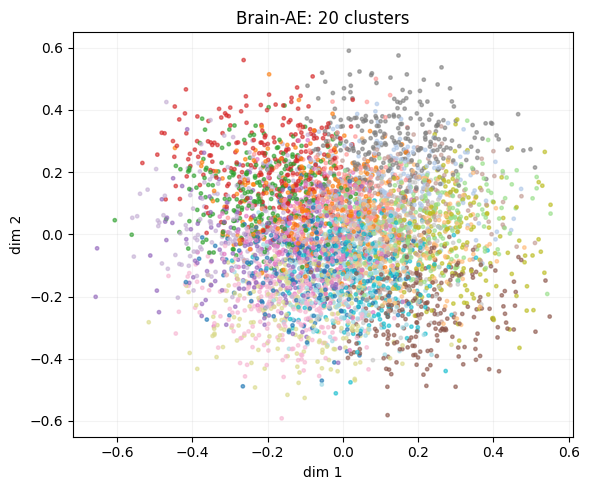


Largest CLIP clusters (top labels):
8 n= 431 top= [('bird', 37), ('nematode', 2), ('brain_coral', 2), ('puffer', 2), ('bullfrog', 2)]
7 n= 392 top= [('cell phone', 4), ('remote', 4), ('tv', 3), ('spotlight', 2), ('oscilloscope', 2)]
6 n= 373 top= [('Fabricstore', 4), ('Elevator Outside', 4), ('Nailsalon', 4), ('Yogastudio', 4), ('Exerciseequipment', 4)]
1 n= 345 top= [('dog', 49), ('cat', 29), ('Tibetan_mastiff', 2), ('Newfoundland', 2), ('Boston_bull', 2)]
17 n= 330 top= [('person', 17), ('tv', 10), ('cat', 9), ('cell phone', 8), ('fire hydrant', 7)]
12 n= 317 top= [('potted plant', 30), ('bottle', 26), ('toilet', 20), ('sink', 17), ('tv', 16)]
3 n= 313 top= [('person', 35), ('tie', 29), ('bottle', 18), ('couch', 16), ('cell phone', 14)]
5 n= 299 top= [('clock', 51), ('car', 30), ('bicycle', 15), ('umbrella', 13), ('person', 11)]

Largest Brain-AE clusters (top labels):
18 n= 276 top= [('person', 22), ('car', 8), ('dining table', 5), ('refrigerator', 4), ('couch', 4)]
14 n= 274 top= 

In [ ]:
# --- Run clustering on CLIP vs Brain-AE and visualize ---
N_CLUSTERS = 8
SEED = 0

clip_cluster = kmeans_cosine(E_clip, n_clusters=N_CLUSTERS, seed=SEED)
brain_cluster = kmeans_cosine(E_brain, n_clusters=N_CLUSTERS, seed=SEED)

clip_2d = embed_2d(E_clip, seed=SEED)
brain_2d = embed_2d(E_brain, seed=SEED)

plot_embedding_with_clusters(clip_2d, clip_cluster, title=f"CLIP: {N_CLUSTERS} clusters" )
plot_embedding_with_clusters(brain_2d, brain_cluster, title=f"Brain-AE: {N_CLUSTERS} clusters" )

# quick: show how semantically coherent clusters are (top primary labels)
clip_summary = summarize_clusters(cluster_id=clip_cluster, labels_list=labels, top_k=5)
brain_summary = summarize_clusters(cluster_id=brain_cluster, labels_list=labels, top_k=5)

print("\nLargest CLIP clusters (top labels):")
for r in clip_summary[:8]:
    print(r["cluster"], "n=", r["n"], "top=", r["top_labels"])

print("\nLargest Brain-AE clusters (top labels):")
for r in brain_summary[:8]:
    print(r["cluster"], "n=", r["n"], "top=", r["top_labels"])

In [26]:
# --- Nearest neighbours for specific query labels (and compare CLIP vs Brain-AE) ---
def cosine_similarity_matrix(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    x = l2_normalize_rows(x)
    y = l2_normalize_rows(y)
    return x @ y.T

def topk_cosine_neighbors(x: np.ndarray, *, query_idx: int, k: int = 10) -> list[tuple[int, float]]:
    """Return (index, cosine_sim) of top-k neighbors excluding self."""
    sims = cosine_similarity_matrix(x[query_idx:query_idx+1], x)[0]
    sims[query_idx] = -np.inf
    top = np.argpartition(-sims, kth=min(k, sims.size-1))[:k]
    top = top[np.argsort(-sims[top])]
    return [(int(i), float(sims[i])) for i in top]

def any_label_contains(lbls: Any, needle: str) -> bool:
    if lbls is None:
        return False
    needle = needle.lower()
    if isinstance(lbls, (list, tuple)):
        return any(needle in str(x).lower() for x in lbls)
    return needle in str(lbls).lower()

def find_first_index_with_label(needle: str) -> int | None:
    for i, lbls in enumerate(labels):
        if any_label_contains(lbls, needle):
            return i
    return None

def describe_index(i: int) -> str:
    lbls = labels[i] if i < len(labels) else None
    name = imgnames[i] if i < len(imgnames) else "?"
    return f"{i:>4d}  {name}  labels={lbls}"

def show_neighbors_for_label(needle: str, *, k: int = 10) -> None:
    q = find_first_index_with_label(needle)
    if q is None:
        print(f"No image found with label containing '{needle}'")
        return
    print(f"\nQuery '{needle}' -> index {q}")
    print("query:", describe_index(q))

    nn_clip = topk_cosine_neighbors(E_clip, query_idx=q, k=k)
    nn_brain = topk_cosine_neighbors(E_brain, query_idx=q, k=k)

    print("\nTop neighbors in CLIP (cosine sim):")
    for j, sim in nn_clip:
        print(f"  sim={sim:+.4f}  {describe_index(j)}")

    print("\nTop neighbors in Brain-AE (cosine sim):")
    for j, sim in nn_brain:
        print(f"  sim={sim:+.4f}  {describe_index(j)}")

In [27]:
# --- Run a few label queries ---
for q in ["dog", "plane", "house"]:
    show_neighbors_for_label(q, k=10)


Query 'dog' -> index 122
query:  122  COCO_train2014_000000523272.jpg  labels=['dog', 'car', 'truck', 'traffic light', 'person']

Top neighbors in CLIP (cosine sim):
  sim=+0.7504  1121  COCO_train2014_000000340734.jpg  labels=['dog', 'truck']
  sim=+0.7402  2141  COCO_train2014_000000438751.jpg  labels=['dog', 'truck']
  sim=+0.7054  3387  COCO_train2014_000000300476.jpg  labels=['dog', 'car', 'truck']
  sim=+0.6823  4409  COCO_train2014_000000173987.jpg  labels=['dog']
  sim=+0.6776  1986  COCO_train2014_000000403184.jpg  labels=['dog', 'car', 'person']
  sim=+0.6688  3662  COCO_train2014_000000070421.jpg  labels=['dog', 'car']
  sim=+0.6674  2039  COCO_train2014_000000208849.jpg  labels=['dog', 'car']
  sim=+0.6594   402  COCO_train2014_000000257690.jpg  labels=['dog', 'truck']
  sim=+0.6497  3974  n02093428_4654.JPEG  labels=['American_Staffordshire_terrier']
  sim=+0.6473  3720  COCO_train2014_000000406595.jpg  labels=['truck']

Top neighbors in Brain-AE (cosine sim):
  sim=+0.32